Group Members: Nicolas Banatt, Annanya Jain, James McDermott, Yanran Jia

In [2865]:
!python --version

Python 3.12.1


In [2866]:
%pip install pandas

Note: you may need to restart the kernel to use updated packages.


In [2867]:
import pandas as pd

In [2868]:
df = pd.read_csv('MergedData_clean.csv')

df.head()

,Participant,ID,Gender,Group,Race,Ethnicity,Assmnt,Avg_Daily_Week_Min,Avg_Daily_Sed_Week_Min,Avg_Daily_Light_Week_Min,...,Age,BMI,RRV_Pgoal,RRV_Agoal,RRVscore,RRVch,oesPos,oesNeg,pretieqPref,pretieqTole
0,407-0001,1,M,0.0,White,Not Hispanic or Latino,baseline,910.0,629.0,256.0,...,32.0,32.5,ellip,read,0.50,0.00,90.0,3.33,30.0,24.0
1,407-0001,1,M,0.0,White,Not Hispanic or Latino,endposttr,824.0,521.0,252.0,...,33.0,31.7,tmill,read,1.00,0.50,91.0,13.33,32.0,23.0
2,407-0001,1,M,0.0,White,Not Hispanic or Latino,pstwash,848.0,579.0,229.0,...,33.0,32.2,tmill,read,0.75,0.25,90.5,8.33,30.0,39.0
3,407-0002,2,M,0.0,White,Not Hispanic or Latino,baseline,680.0,546.0,127.0,...,33.0,32.1,cycle,wrdgms,0.00,0.00,83.0,48.33,26.0,20.0
4,407-0002,2,M,0.0,White,Not Hispanic or Latino,endposttr,622.0,510.0,102.0,...,33.0,32.0,ellip,cwrdpz,0.00,0.00,71.0,46.17,23.0,19.0


In [2869]:
# Remove baseline assessments, since we know RRVch will be 0
df = df[df["Assmnt"].str.lower() != "baseline"]

df.head()

,Participant,ID,Gender,Group,Race,Ethnicity,Assmnt,Avg_Daily_Week_Min,Avg_Daily_Sed_Week_Min,Avg_Daily_Light_Week_Min,...,Age,BMI,RRV_Pgoal,RRV_Agoal,RRVscore,RRVch,oesPos,oesNeg,pretieqPref,pretieqTole
1,407-0001,1,M,0.0,White,Not Hispanic or Latino,endposttr,824.0,521.0,252.0,...,33.0,31.7,tmill,read,1.00,0.50,91.0,13.330,32.0,23.0
2,407-0001,1,M,0.0,White,Not Hispanic or Latino,pstwash,848.0,579.0,229.0,...,33.0,32.2,tmill,read,0.75,0.25,90.5,8.330,30.0,39.0
4,407-0002,2,M,0.0,White,Not Hispanic or Latino,endposttr,622.0,510.0,102.0,...,33.0,32.0,ellip,cwrdpz,0.00,0.00,71.0,46.170,23.0,19.0
5,407-0002,2,M,0.0,White,Not Hispanic or Latino,pstwash,641.0,519.0,117.0,...,33.0,31.7,cycle,wrdgms,0.00,0.00,77.0,47.250,22.0,19.0
7,407-0003,3,F,0.0,White,Not Hispanic or Latino,pstwash,753.0,434.0,300.0,...,39.0,23.8,tmill,read,0.75,0.00,91.1,32.335,23.0,27.0


In [2870]:
# Change RRVch (our target) to binary label for classification
df["RRV_label"] = (df["RRVch"] > 0).astype(int)

df.head()

,Participant,ID,Gender,Group,Race,Ethnicity,Assmnt,Avg_Daily_Week_Min,Avg_Daily_Sed_Week_Min,Avg_Daily_Light_Week_Min,...,BMI,RRV_Pgoal,RRV_Agoal,RRVscore,RRVch,oesPos,oesNeg,pretieqPref,pretieqTole,RRV_label
1,407-0001,1,M,0.0,White,Not Hispanic or Latino,endposttr,824.0,521.0,252.0,...,31.7,tmill,read,1.00,0.50,91.0,13.330,32.0,23.0,1
2,407-0001,1,M,0.0,White,Not Hispanic or Latino,pstwash,848.0,579.0,229.0,...,32.2,tmill,read,0.75,0.25,90.5,8.330,30.0,39.0,1
4,407-0002,2,M,0.0,White,Not Hispanic or Latino,endposttr,622.0,510.0,102.0,...,32.0,ellip,cwrdpz,0.00,0.00,71.0,46.170,23.0,19.0,0
5,407-0002,2,M,0.0,White,Not Hispanic or Latino,pstwash,641.0,519.0,117.0,...,31.7,cycle,wrdgms,0.00,0.00,77.0,47.250,22.0,19.0,0
7,407-0003,3,F,0.0,White,Not Hispanic or Latino,pstwash,753.0,434.0,300.0,...,23.8,tmill,read,0.75,0.00,91.1,32.335,23.0,27.0,0


## K-Nearest Neighbors

In [2871]:
from sklearn.preprocessing import MinMaxScaler
# James

knn_df = df.copy()

knn_df["Assmnt"] = knn_df["Assmnt"].map({
    "endposttr": 6,
    "pstwash": 10
})

knn_df["Gender"] = knn_df["Gender"].map({
    "M": 0,
    "F": 1
})

knn_df["RRV_Pgoal"] = knn_df["RRV_Pgoal"].map({
    "tmill": 0,
    "ellip": 1,
    "cycle": 2
})

knn_df["RRV_Agoal"] = knn_df["RRV_Agoal"].map({
    "read": 0,
    "wrdgms": 1,
    "cwrdpz": 2
})

attr = knn_df.drop(columns = ['Gender','Group','Height','Age','BMI','Participant','ID','Race','Ethnicity','Avg_Daily_Week_Min','RRVch','oesPos', 'oesNeg', 'pretieqPref', 'pretieqTole','RRV_label'])  # features 'oesPos', 'oesNeg', 'pretieqPref', 'pretieqTole'
target = knn_df['RRV_label']  # target variable
attr.head()

,Assmnt,Avg_Daily_Sed_Week_Min,Avg_Daily_Light_Week_Min,Avg_Daily_Mod_Week_Min,Avg_Daily_Vig_Week_Min,Avg_Daily_Very_Vig_Week_Min,RRV_Pgoal,RRV_Agoal,RRVscore
1,6,521.0,252.0,47.0,4.0,0.0,0,0,1.00
2,10,579.0,229.0,40.0,0.0,0.0,0,0,0.75
4,6,510.0,102.0,11.0,0.0,0.0,1,2,0.00
5,10,519.0,117.0,5.0,0.0,0.0,2,1,0.00
7,10,434.0,300.0,18.0,0.0,0.0,0,0,0.75


In [2872]:
scaler = MinMaxScaler()
attr = pd.DataFrame(scaler.fit_transform(attr), columns=attr.columns)
attr.head()

,Assmnt,Avg_Daily_Sed_Week_Min,Avg_Daily_Light_Week_Min,Avg_Daily_Mod_Week_Min,Avg_Daily_Vig_Week_Min,Avg_Daily_Very_Vig_Week_Min,RRV_Pgoal,RRV_Agoal,RRVscore
0,0.0,0.277690,0.585714,0.783333,0.571429,0.0,0.0,0.0,1.00
1,1.0,0.323576,0.530952,0.666667,0.000000,0.0,0.0,0.0,0.75
2,0.0,0.268987,0.228571,0.183333,0.000000,0.0,0.5,1.0,0.00
3,1.0,0.276108,0.264286,0.083333,0.000000,0.0,1.0,0.5,0.00
4,1.0,0.208861,0.700000,0.300000,0.000000,0.0,0.0,0.0,0.75


In [2873]:
from sklearn.model_selection._split import train_test_split

attr_train, attr_test, target_train,target_test  = sklearn.model_selection._split.train_test_split(attr, target, test_size = 0.25, shuffle = True)
target_train.head()
attr_train.head()

,Assmnt,Avg_Daily_Sed_Week_Min,Avg_Daily_Light_Week_Min,Avg_Daily_Mod_Week_Min,Avg_Daily_Vig_Week_Min,Avg_Daily_Very_Vig_Week_Min,RRV_Pgoal,RRV_Agoal,RRVscore
108,1.0,0.705696,0.580952,0.600000,0.285714,0.0,0.5,1.0,0.857143
75,1.0,0.166930,0.433333,0.516667,0.428571,0.0,0.5,1.0,0.833333
7,0.0,0.189873,0.750000,0.300000,0.285714,0.0,0.5,0.5,0.000000
121,0.0,0.876582,0.352381,0.116667,0.000000,0.0,0.5,0.5,0.000000
64,1.0,0.161392,0.414286,0.433333,0.142857,0.0,0.5,0.5,0.666667


In [2874]:
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import accuracy_score

k_values = [3, 5, 10]
 
for k in k_values:
    knn = KNeighborsClassifier(n_neighbors = k)
    knn.fit(attr_train, target_train)
    target_pred = knn.predict(attr_test)
    accuracy = accuracy_score(target_test,target_pred ) 
    print(f'Accuracy of model with k = {k}: {accuracy}')
    print('')

Accuracy of model with k = 3: 0.7096774193548387

Accuracy of model with k = 5: 0.6774193548387096

Accuracy of model with k = 10: 0.7096774193548387



In [2875]:
from sklearn.metrics import accuracy_score
from sklearn.metrics import classification_report
from sklearn.metrics import confusion_matrix

cm=confusion_matrix(target_test, target_pred)

print('Confusion Matrix')
print(confusion_matrix(target_test, target_pred))
print()
print('Accuracy score')
print(accuracy_score(target_test, target_pred))
print()
print('Classification Report')
print(classification_report(target_test, target_pred))

Confusion Matrix
[[17  5]
 [ 4  5]]

Accuracy score
0.7096774193548387

Classification Report
              precision    recall  f1-score   support

           0       0.81      0.77      0.79        22
           1       0.50      0.56      0.53         9

    accuracy                           0.71        31
   macro avg       0.65      0.66      0.66        31
weighted avg       0.72      0.71      0.71        31



In [2876]:
test_actual=attr_test
test_actual['target_pred']=target_pred
test_actual['test_actual']=target_test
test_actual.head()

,Assmnt,Avg_Daily_Sed_Week_Min,Avg_Daily_Light_Week_Min,Avg_Daily_Mod_Week_Min,Avg_Daily_Vig_Week_Min,Avg_Daily_Very_Vig_Week_Min,RRV_Pgoal,RRV_Agoal,RRVscore,target_pred,test_actual
77,1.0,0.260285,0.685714,0.583333,0.285714,0.0,0.5,0.0,0.666667,1,NaN
16,1.0,0.177215,0.776190,0.783333,0.714286,0.0,0.0,0.0,1.000000,1,NaN
113,0.0,0.768987,0.530952,0.150000,0.000000,0.0,1.0,1.0,0.833333,1,NaN
69,1.0,0.109968,0.221429,0.466667,0.428571,0.0,0.0,1.0,0.500000,0,NaN
117,0.0,0.772152,0.652381,0.216667,0.000000,0.0,0.5,1.0,1.000000,0,0.0


In [2877]:
freq_table =pd.crosstab( test_actual['test_actual'], test_actual['target_pred'])
print("Confusion Matrix")
print(freq_table)

Confusion Matrix
target_pred  0  1
test_actual      
0.0          1  2


[Text(0, 0.5, '0(No_Increase)'), Text(0, 1.5, '1(Increase_Motiv)')]

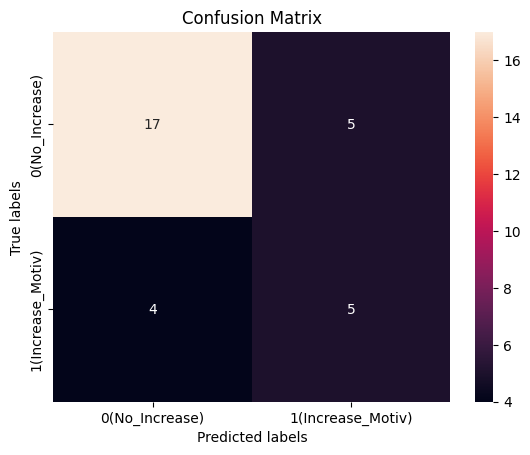

In [2878]:
import seaborn as sns
import matplotlib.pyplot as plt     

ax= plt.subplot()
sns.heatmap(cm, annot=True, fmt='g', ax=ax);  #annot=True to annotate cells, ftm='g' to disable scientific notation

# labels, title and ticks
ax.set_xlabel('Predicted labels');ax.set_ylabel('True labels'); 
ax.set_title('Confusion Matrix'); 
ax.xaxis.set_ticklabels(['0(No_Increase)', '1(Increase_Motiv)'])
ax.yaxis.set_ticklabels(['0(No_Increase)', '1(Increase_Motiv)'])

## CART

## Naive Bayes

In [2879]:
# James


## Random Forest

In [2880]:
# James


## Artificial Neural Network

## Hierarchical Clustering

## K-Means Clustering

## Support Vector Machine

## MiniSOM